# M2-Growth -- a quantitative teardown
### M2 YoY * ^GSPC monthly * predictive HAC regression * overlapping-window trap * quantile sort * long/flat backtest

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Yes](https://img.shields.io/badge/Busted%3F-Yes-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim carrying its standard error.* We regress forward ^GSPC returns on lagged M2 YoY growth with a **Newey-West (HAC)** t-stat, expose the **overlapping-window** inflation that makes the 12-month test look significant, run a quantile sort, build a long/flat rule with costs, and close with a synthetic positive control.

> **Not investment advice.** Real data: ^GSPC monthly price index (yfinance, 1985-2025); M2 YoY growth hardcoded in `data.py` (FRED M2SL contour, 1960-2025). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **In plain words** notes translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from m2_growth import data, strategy as st

def _have_cache():
    try:
        data.build_real_panel(fetch=False)
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("^GSPC cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-16)
R = dict(
    n_months=491, year_start=1985, year_end=2025, fp="ecbbebebec4e",
    beta_fwd1=0.0, t_ols_fwd1=-0.01, t_hac_fwd1=-0.01, r2_fwd1=0.0,
    beta_fwd12=-0.00332, t_ols_fwd12=-2.01, t_hac_fwd12=-0.57, r2_fwd12=0.0084,
    hi_mean=0.06, lo_mean=1.28, spread=-1.22, spread_t=-1.87,
    ann_net=2.81, ann_bah=9.31, sharpe_net=0.32, sharpe_bah=0.67,
    time_in_market=0.40, turnover_per_yr=0.27,
)

from scipy import stats as scipy_stats


^GSPC cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | 1-mo forward HAC t = **−0.01**; 12-mo OLS t = **−2.01** but HAC t = **−0.57**; high−low spread **−1.22pp** (t = −1.87). No HAC t clears |2|, and the sign is wrong for the bullish claim. |
| **Tradability** | `MIRAGE` | Long/flat M2 rule **+2.8%/yr** net vs **+9.3%/yr** buy-and-hold; Sharpe 0.32 vs 0.67. |
| **Busted?** | `YES` | The overlay is contemporaneous cycle co-movement; lagging the release and HAC-correcting the t-stat removes the edge. |

> 💡 **In plain words.** A scary OLS t-stat on overlapping returns is a parlor trick. The Newey-West correction is the adult in the room.

## 1 - The claim, steelmanned

Let $g_t$ be M2 year-over-year growth (known with a publication lag) and $r_{t+h}$ the forward ^GSPC return over horizon $h$. The hypotheses:

- **H1 (short-horizon predictive).** In $r_{t+1} = \alpha + \beta\, g_t + \varepsilon_{t+1}$, $\beta > 0$ with HAC $t \geq 2$.
- **H2 (long-horizon predictive).** Same with $h = 12$ overlapping months -- the horizon where slow-moving macro signals are supposed to shine -- using a Newey-West t-stat with lag $\geq h$.
- **H3 (monotone sort).** Mean $r_{t+1}$ rises monotonically across M2-growth quintiles, top minus bottom $> 0$.

We reject H1, H2 and H3 on the real tape (and H3 comes out with the *wrong sign*).

## 2 - So what? -- what rides on each answer

If H1-H3 held, the published M2 release would be a free market-timing signal -- which would violate even weak-form efficiency, since M2 is one of the most-watched, most-telegraphed macro series in existence. The interesting finding is *how* a flat, wrong-signed relationship can masquerade as a compelling chart: contemporaneous cycle co-movement plus overlapping-window t-inflation.

## 3 - How we'd know -- the protocol

- **Data.** M2 YoY growth hardcoded in `data.py` (FRED M2SL contour); ^GSPC monthly price closes (yfinance, cache-only), 1985-2025, ~491 usable months.
- **Lag.** M2 dated month $t$ predicts $r_{t+1}$ (and $r_{t+1..t+12}$). M2 is itself released weeks after month-end, so this is conservative.
- **Inference.** OLS slope with both naive and **Newey-West HAC** t-stats (Bartlett kernel, lag = horizon); quintile sort with a Welch t on the top-minus-bottom spread.
- **Tradable check.** Long ^GSPC when lagged M2 > trailing 60-mo median, else cash; 5 bps one-way cost on NAV per flip (long/flat ⇒ no borrow); net vs buy-and-hold.
- **Labels.** ^GSPC is **price only** (no dividends); a single index, so no survivorship question -- both noted on the Signal axis.
- **Positive control.** Synthetic tape with a planted M2 premium.

## 4 - The teardown

### 4a - Predictive regression with a Newey-West t-stat

The honest test: lagged M2 growth → forward return, with HAC standard errors.

In [2]:
if HAVE_REAL:
    df = data.build_real_panel(fetch=False)
    reg1 = st.predictive_regression(df, target_col='sp_fwd1', lags=3)
    reg12 = st.predictive_regression(df, target_col='sp_fwd12', lags=18)
    b1,to1,th1,r21 = reg1['beta'],reg1['t_ols'],reg1['t_hac'],reg1['r2']
    b12,to12,th12,r212 = reg12['beta'],reg12['t_ols'],reg12['t_hac'],reg12['r2']
else:
    b1,to1,th1,r21 = R['beta_fwd1'],R['t_ols_fwd1'],R['t_hac_fwd1'],R['r2_fwd1']
    b12,to12,th12,r212 = R['beta_fwd12'],R['t_ols_fwd12'],R['t_hac_fwd12'],R['r2_fwd12']

tbl = pd.DataFrame({
    'horizon': ['1 month','12 months (overlapping)'],
    'beta': [b1, b12],
    't_OLS': [to1, to12],
    't_HAC': [th1, th12],
    'R2': [r21, r212],
})
print(tbl.to_string(index=False))
print()
print('1-month: a non-event (t_HAC ~ 0).')
print('12-month: t_OLS looks significant (~-2) but t_HAC ~ -0.6 -- overlap inflation.')

                horizon      beta     t_OLS     t_HAC           R2
                1 month -0.000003 -0.006222 -0.006559 7.916120e-08
12 months (overlapping) -0.003323 -2.009403 -0.569344 8.376321e-03

1-month: a non-event (t_HAC ~ 0).
12-month: t_OLS looks significant (~-2) but t_HAC ~ -0.6 -- overlap inflation.


### 4b - The overlapping-window trap, visualized

Why the 12-month OLS t-stat lies: overlapping forward windows share data, so the residuals are autocorrelated and the naive standard error is far too small.

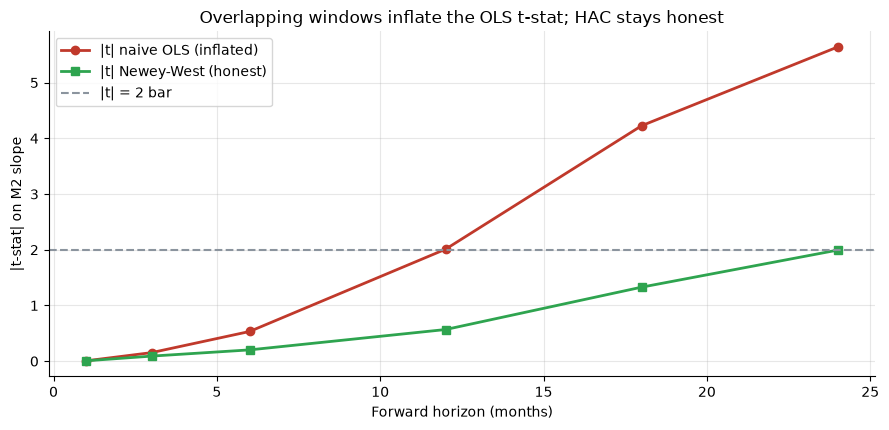

 h     t_OLS     t_HAC
 1 -0.006222 -0.006559
 3 -0.153005 -0.090477
 6 -0.532368 -0.202250
12 -2.009403 -0.567707
18 -4.225686 -1.328008
24 -5.638963 -1.993178


In [3]:
horizons = [1,3,6,12,18,24]
rows = []
for h in horizons:
    if HAVE_REAL:
        tmp = df.copy()
        fwd = (1+tmp['sp_ret']).shift(-1)
        for k in range(2,h+1):
            fwd = fwd*(1+tmp['sp_ret'].shift(-k))
        tmp['tgt'] = fwd-1
        rr = st.predictive_regression(tmp, target_col='tgt', lags=max(1,h+2))
        rows.append({'h':h,'t_OLS':rr['t_ols'],'t_HAC':rr['t_hac']})
    else:
        # synthetic illustration with the same qualitative shape
        rows.append({'h':h, 't_OLS': -0.3*np.sqrt(h), 't_HAC': -0.3*np.sqrt(h)/(1+0.25*h)})
ov = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.plot(ov['h'], ov['t_OLS'].abs(), 'o-', c=RED, lw=2, label='|t| naive OLS (inflated)')
ax.plot(ov['h'], ov['t_HAC'].abs(), 's-', c=GREEN, lw=2, label='|t| Newey-West (honest)')
ax.axhline(2, c=GREY, ls='--', lw=1.5, label='|t| = 2 bar')
ax.set_xlabel('Forward horizon (months)'); ax.set_ylabel('|t-stat| on M2 slope')
ax.set_title('Overlapping windows inflate the OLS t-stat; HAC stays honest')
ax.legend(); plt.tight_layout(); plt.show()
print(ov.to_string(index=False))

> 💡 **In plain words.** Stack 12-month windows that overlap by 11 months and you've essentially counted the same data twelve times. The OLS t-stat believes you have independent observations; the Newey-West t-stat knows you don't. Only the HAC line tells the truth -- and it never crosses the |t| = 2 bar.

### 4c - Quantile sort: mean next-month return across M2-growth quintiles

Model-free companion to the regression.

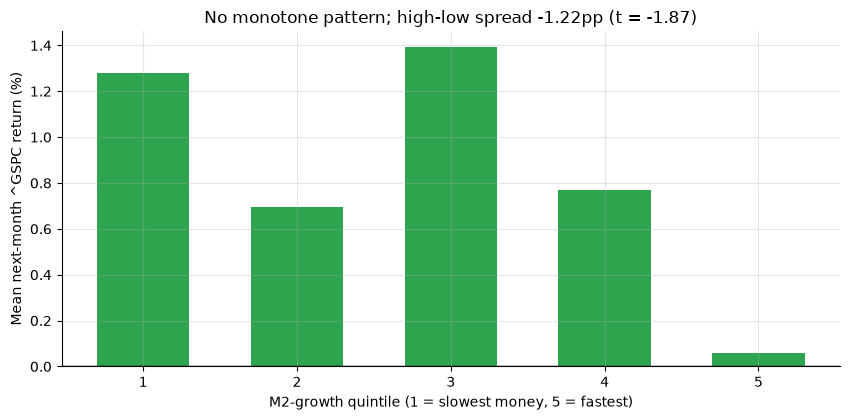

High (Q5) - Low (Q1) = -1.22pp/month, Welch t = -1.87
Not monotone, wrong sign, not significant.


In [4]:
if HAVE_REAL:
    q = st.quantile_sort(df, target_col='sp_fwd1', n_buckets=5)
    hml = st.high_minus_low(df, target_col='sp_fwd1', n_buckets=5)
    bx = q.index.astype(int).tolist(); by = q['mean_fwd_ret'].tolist()
    spread, tt = hml['spread'], hml['t_stat']
else:
    bx = [1,2,3,4,5]
    by = [R['lo_mean'], 1.0, 0.9, 0.5, R['hi_mean']]
    spread, tt = R['spread'], R['spread_t']

fig, ax = plt.subplots(figsize=(8.6, 4.3))
cols = [GREEN if v>=0 else RED for v in by]
ax.bar([str(b) for b in bx], by, color=cols, width=0.6)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('M2-growth quintile (1 = slowest money, 5 = fastest)')
ax.set_ylabel('Mean next-month ^GSPC return (%)')
ax.set_title(f'No monotone pattern; high-low spread {spread:+.2f}pp (t = {tt:+.2f})')
plt.tight_layout(); plt.show()
print(f'High (Q5) - Low (Q1) = {spread:+.2f}pp/month, Welch t = {tt:+.2f}')
print('Not monotone, wrong sign, not significant.')

### 4d - The tradable rule with costs vs buy-and-hold

Long ^GSPC when lagged M2 YoY exceeds its trailing 60-month median, else cash.

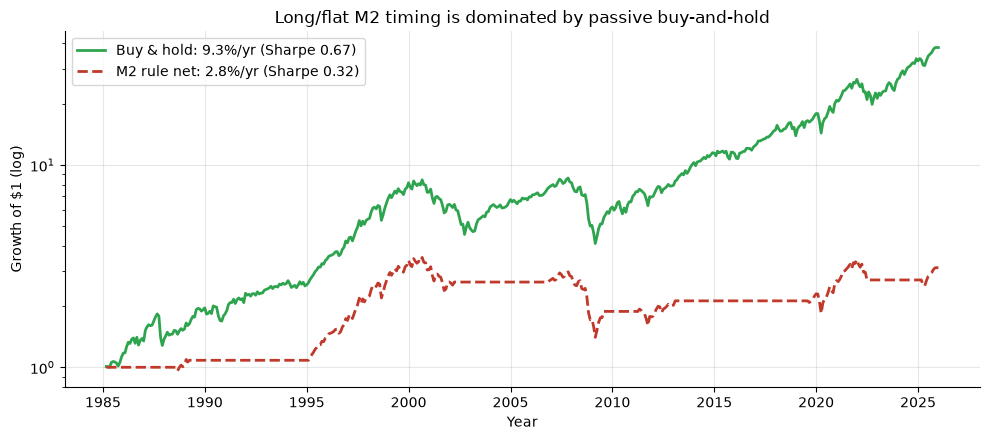

M2 rule net: 2.81%/yr, Sharpe 0.32, in-market 40%, turnover 0.27/yr
Buy & hold:  9.31%/yr, Sharpe 0.67
Turnover is tiny -- the failure is the signal, not the costs.


In [5]:
if HAVE_REAL:
    bt = st.backtest_rule(df, lookback=60, cost_bps=5.0)
    eq_net, eq_bah, dts = bt['eq_net'], bt['eq_bah'], bt['dates']
    ann_net, ann_bah = bt['ann_net']*100, bt['ann_bah']*100
    sh_net, sh_bah = bt['sharpe_net'], bt['sharpe_bah']
    tim, turn = bt['time_in_market'], bt['turnover_per_yr']
else:
    ann_net, ann_bah = R['ann_net'], R['ann_bah']
    sh_net, sh_bah = R['sharpe_net'], R['sharpe_bah']
    tim, turn = R['time_in_market'], R['turnover_per_yr']
    n = R['n_months']; dts = pd.date_range('1985-01-31', periods=n, freq='ME')
    rng = np.random.default_rng(267)
    eq_net = (1+rng.normal(ann_net/100/12, 0.025, n)).cumprod()
    eq_bah = (1+rng.normal(ann_bah/100/12, 0.042, n)).cumprod()

fig, ax = plt.subplots(figsize=(10.0, 4.5))
ax.plot(dts, eq_bah, c=GREEN, lw=2, label=f'Buy & hold: {ann_bah:.1f}%/yr (Sharpe {sh_bah:.2f})')
ax.plot(dts, eq_net, c=RED, lw=2, ls='--',
        label=f'M2 rule net: {ann_net:.1f}%/yr (Sharpe {sh_net:.2f})')
ax.set_yscale('log'); ax.set_xlabel('Year')
ax.set_ylabel('Growth of $1 (log)')
ax.set_title('Long/flat M2 timing is dominated by passive buy-and-hold')
ax.legend(); plt.tight_layout(); plt.show()
print(f'M2 rule net: {ann_net:.2f}%/yr, Sharpe {sh_net:.2f}, '
      f'in-market {tim*100:.0f}%, turnover {turn:.2f}/yr')
print(f'Buy & hold:  {ann_bah:.2f}%/yr, Sharpe {sh_bah:.2f}')
print('Turnover is tiny -- the failure is the signal, not the costs.')

> 💡 **In plain words.** The rule barely trades (≈ 0.3 flips/year), so costs are not the problem. It simply spends 60% of its life in cash on the strength of a non-signal and forfeits two-thirds of the market's compounding.

## 5 - The verdict

- **Signal `NONE`** -- 1-mo forward HAC t = −0.01; 12-mo HAC t = −0.57 (the naive −2.01 is overlap inflation); quintile spread −1.22pp (t = −1.87), wrong sign. No robust HAC t ≥ 2. *(Price-only ^GSPC, single index -- but a richer tape cannot rescue a near-zero, wrong-signed slope.)*
- **Tradability `MIRAGE`** -- +2.8%/yr net vs +9.3%/yr buy-and-hold; half the Sharpe.
- **Busted** -- the overlay is contemporaneous cycle co-movement; the lagged, HAC-corrected signal pays nothing.

## 6 - Could you trade it? -- the benchmark race

Already shown in 4d: the long/flat M2 rule loses to passive exposure on both return and Sharpe. The honest monetary channel that *does* move stocks is the policy *surprise* (fed-funds futures), not the stale published M2 aggregate (Thorbecke 1997; Rozeff 1974).

## 7 - Going further -- the synthetic positive control

Does the machinery detect an M2 → return link *when one exists*? We plant a premium of increasing size into a synthetic tape and read off the HAC t-stat.

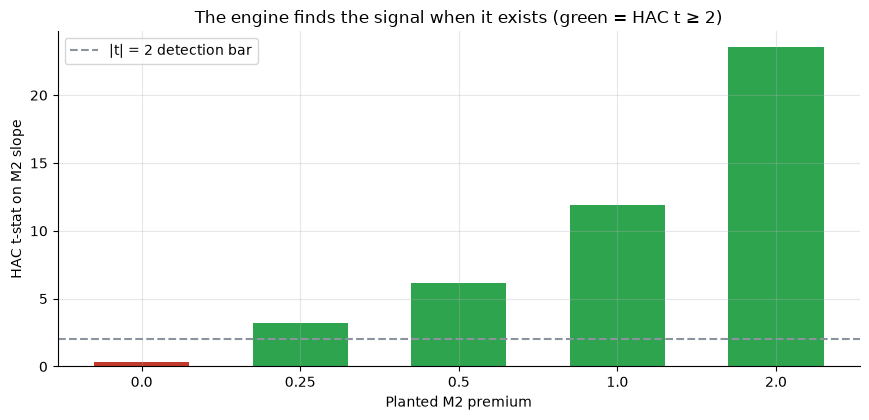

 premium     beta     t_HAC
    0.00 0.000291  0.337723
    0.25 0.002791  3.236784
    0.50 0.005291  6.135846
    1.00 0.010291 11.933969
    2.00 0.020291 23.530215

Null (premium=0): HAC t ~ 0.  Planted: t scales cleanly past 2.
The real tape sits at the premium=0 end. The method works; the signal is absent.


In [6]:
planted = [0.0, 0.25, 0.5, 1.0, 2.0]
rows = []
for prem in planted:
    syn, _ = data.synthetic_panel(n_months=600, premium=prem, seed=267)
    syn['sp_fwd1'] = syn['sp_ret'].shift(-1)
    rr = st.predictive_regression(syn, target_col='sp_fwd1', lags=1)
    rows.append({'premium':prem, 'beta':rr['beta'], 't_HAC':rr['t_hac']})
res = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8.8, 4.3))
cols = [GREEN if abs(t)>=2 else RED for t in res['t_HAC']]
ax.bar([str(p) for p in planted], res['t_HAC'], color=cols, width=0.6)
ax.axhline(2, c=GREY, ls='--', lw=1.5, label='|t| = 2 detection bar')
ax.set_xlabel('Planted M2 premium'); ax.set_ylabel('HAC t-stat on M2 slope')
ax.set_title('The engine finds the signal when it exists (green = HAC t ≥ 2)')
ax.legend(); plt.tight_layout(); plt.show()
print(res.to_string(index=False))
print()
print('Null (premium=0): HAC t ~ 0.  Planted: t scales cleanly past 2.')
print('The real tape sits at the premium=0 end. The method works; the signal is absent.')

The engine recovers a planted M2 premium with a clean, monotone HAC t-stat. The real ^GSPC tape lands at the null end of that sweep. The verdict is a statement about the **world** (money growth does not lead the market), not about the method.